# Deepfake Detection Multiclass (5-Class) Edition
**FaceForensics++ | MobileNetV2 | Official Split**

### Classes
| ID | Class | Description |
|----|-------|-------------|
| 0 | **Real** | Original YouTube videos |
| 1 | **Deepfakes** | Identity swap via autoencoder |
| 2 | **Face2Face** | Facial reenactment |
| 3 | **FaceSwap** | Face replacement (SimSwap-style) |
| 4 | **NeuralTextures** | Texture-based rendering manipulation |

### Training Strategy -3-Stage Progressive Fine-Tuning
| Stage | Backbone | Epochs | LR (backbone) | Mixup | Purpose |
|-------|----------|--------|---------------|-------|---------|
| 1 | Fully frozen | 10 | - | ✗ | Head warm-up |
| 2 | Last 8 blocks | 20 | 3e-5 | ✓ | Backbone adaptation |
| 3 | All blocks | 10 | 5e-6 | ✓ | Full fine-tune (low LR) |

### Key Design Decisions
- **No GaussianBlur** deepfake artifacts are high-frequency; blur destroys them
- **Mixup augmentation** (α=0.3)- smooths decision boundaries between similar fake classes
- **Differential LR** per stage - protects early backbone layers from forgetting ImageNet features
- **WeightedRandomSampler + class-weighted loss** - dual correction for class imbalance
- **CosineAnnealingLR** in all stages- smooth LR decay, avoids StepLR discontinuities


In [ ]:
import os, json, random, shutil
from dataclasses import dataclass
from pathlib import Path

# PATH SETUP

BASE_DIR = r'C:\Users\DPQUAI250117\Desktop\deep_fake_version_3'

# Output folder — where checkpoints, CSVs, and plots will be saved
OUTPUT_DIR = os.path.join(BASE_DIR, 'output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# MULTICLASS LABEL MAPPING
# 0=Real | 1=Deepfakes | 2=Face2Face | 3=FaceSwap | 4=NeuralTextures

CLASS_MAP   = {'real': 0, 'Deepfakes': 1, 'Face2Face': 2,
               'FaceSwap': 3, 'NeuralTextures': 4}
CLASS_NAMES = ['Real', 'Deepfakes', 'Face2Face', 'FaceSwap', 'NeuralTextures']
NUM_CLASSES = len(CLASS_MAP)  # 5

@dataclass
class CFG:
    root_dir:    str = BASE_DIR
    work_dir:    str = OUTPUT_DIR
    dataset_dir: str = os.path.join(BASE_DIR, 'dataset_300')
    index_csv:   str = os.path.join(OUTPUT_DIR, 'multiclass_index.csv')
    best_ckpt:   str = os.path.join(OUTPUT_DIR, 'best_model_multiclass.pth')

    split_train_json: str = os.path.join(BASE_DIR, 'train.json')
    split_val_json:   str = os.path.join(BASE_DIR, 'val.json')
    split_test_json:  str = os.path.join(BASE_DIR, 'test.json')

    compression:           str  = 'c23'
    max_videos_per_folder: int  = 300
    frames_per_video:      int  = 30
    image_size:            int  = 224

    do_download:  bool = False
    skip_extract: bool = True
    download_script_url: str = 'https://kaldir.vc.in.tum.de/faceforensics_download_v4.py'
    server: str = 'EU2'

    batch_size:   int = 32
    num_workers:  int = 0   # Windows fix: multiprocessing causes DataLoader hang

    # Training schedule
    stage1_epochs: int   = 10
    stage1_lr:     float = 1e-3

    stage2_epochs: int   = 20
    stage2_lr:     float = 3e-5

    stage3_epochs: int   = 15
    stage3_lr:      float = 1e-5
    stage3_lr_late: float = 2e-5
    stage3_lr_head: float = 5e-5

    use_tta:    bool = True
    tta_n_aug:  int  = 7

    patience:        int   = 7
    weight_decay:    float = 1e-4
    label_smoothing: float = 0.0

    use_mixup:   bool  = True
    mixup_alpha: float = 0.3

    use_weighted_sampler:    bool = True
    use_class_weighted_loss: bool = True

cfg = CFG()

# Sanity check
missing = []
for name, path in [
    ('dataset_300', cfg.dataset_dir),
    ('train.json',  cfg.split_train_json),
    ('val.json',    cfg.split_val_json),
    ('test.json',   cfg.split_test_json),
]:
    exists = os.path.exists(path)
    print(f"{'✅' if exists else '❌'}  {name:<15} -> {path}")
    if not exists:
        missing.append(name)

if missing:
    print('\n⚠️  Missing files:', missing)
    raise FileNotFoundError(f'Missing: {missing}')

print(f'\nNUM_CLASSES : {NUM_CLASSES}')
print('Config ready ✅')


✅  dataset_300     -> C:\Users\DPQUAI250117\Desktop\deep_fake_version_3\dataset_300
✅  train.json      -> C:\Users\DPQUAI250117\Desktop\deep_fake_version_3\train.json
✅  val.json        -> C:\Users\DPQUAI250117\Desktop\deep_fake_version_3\val.json
✅  test.json       -> C:\Users\DPQUAI250117\Desktop\deep_fake_version_3\test.json

NUM_CLASSES : 5
Config ready ✅


In [ ]:
SPLIT_FILES = {
    'train': cfg.split_train_json,
    'val'  : cfg.split_val_json,
    'test' : cfg.split_test_json,
}

def load_official_splits():
    split_pairs = {}
    for split_name, fp in SPLIT_FILES.items():
        data = json.loads(Path(fp).read_text())
        pair_keys, ids = set(), set()
        for a, b in data:
            pair_keys.add(f'{a}_{b}')
            ids.add(a)
            ids.add(b)
        split_pairs[split_name] = {'pairs': pair_keys, 'ids': ids}
    return split_pairs

official_splits = load_official_splits()
print('Train pairs:', len(official_splits['train']['pairs']))
print('Val pairs  :', len(official_splits['val']['pairs']))
print('Test pairs :', len(official_splits['test']['pairs']))

# Leakage sanity check (must all be 0)
tr, va, te = [official_splits[s]['pairs'] for s in ['train','val','test']]
print(f'\nOverlap check → train∩val:{len(tr&va)}  train∩test:{len(tr&te)}  val∩test:{len(va&te)}')


Train pairs: 360
Val pairs  : 70
Test pairs : 70

Overlap check → train∩val:0  train∩test:0  val∩test:0


In [ ]:
def build_face_cascade():
    haar = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    return cv2.CascadeClassifier(haar)

def center_crop_square(img):
    h, w = img.shape[:2]
    m = min(h, w)
    y1 = (h - m) // 2; x1 = (w - m) // 2
    return img[y1:y1+m, x1:x1+m]

def detect_face(frame, cascade, pad=0.40):
    gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = cascade.detectMultiScale(gray, 1.1, 5, minSize=(60, 60))
    if len(faces) == 0:
        return None
    x, y, w, h = sorted(faces, key=lambda b: b[2]*b[3], reverse=True)[0]
    cx, cy = x + w/2, y + h/2
    side   = max(w, h) * (1 + pad)
    x1 = int(max(0, cx - side/2)); y1 = int(max(0, cy - side/2))
    x2 = int(min(frame.shape[1], cx + side/2))
    y2 = int(min(frame.shape[0], cy + side/2))
    crop = frame[y1:y2, x1:x2]
    return crop if crop.size > 0 else None

def extract_frames(video_dir, out_dir):
    Path(out_dir).mkdir(parents=True, exist_ok=True)
    videos  = sorted(Path(video_dir).glob('*.mp4'))[:cfg.max_videos_per_folder]
    cascade = build_face_cascade()
    total   = 0
    for vp in videos:
        cap = cv2.VideoCapture(str(vp))
        n   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if n <= 0:
            cap.release(); continue
        step = max(1, n // cfg.frames_per_video)
        base = vp.stem
        for i in range(cfg.frames_per_video):
            cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)
            ok, frame = cap.read()
            if not ok:
                continue
            crop = detect_face(frame, cascade) or center_crop_square(frame)
            crop = cv2.resize(crop, (cfg.image_size, cfg.image_size))
            cv2.imwrite(str(Path(out_dir) / f'{base}_frame{i:02d}.jpg'), crop)
            total += 1
        cap.release()
    print(f'{out_dir} → {total} frames')

def extract_all_frames():
    out_root = Path(cfg.dataset_dir)
    out_root.mkdir(parents=True, exist_ok=True)
    if cfg.skip_extract:
        existing = sum(1 for _ in out_root.rglob('*.jpg'))
        if existing > 0:
            print(f'Frames already exist ({existing} jpgs) — skipping extraction.')
            return
    root = Path(cfg.root_dir)
    extract_frames(str(root / f'original_sequences/youtube/{cfg.compression}/videos'),
                   str(out_root / 'real'))
    for m in ['Deepfakes', 'Face2Face', 'FaceSwap', 'NeuralTextures']:
        extract_frames(
            str(root / f'manipulated_sequences/{m}/{cfg.compression}/videos'),
            str(out_root / m))

extract_all_frames()

Frames already exist (30000 jpgs) — skipping extraction.


In [ ]:
import pandas as pd
def video_id_from_name(fname):
    """
    '004_982_frame00.jpg' → '004_982'  (fake, matches pair_keys)
    '004_frame00.jpg'     → '004'      (real, matches ids)
    """
    return fname.split('_frame')[0]


def build_index_multiclass():
    """
    Multiclass index: target ∈ {0,1,2,3,4} instead of binary {0,1}.

    Fake folders → split by pair membership  (vid ∈ official split pairs)
    Real folder  → split by video-id membership (vid ∈ official split ids)
    """
    data_root = Path(cfg.dataset_dir)
    rows      = []

    found_dirs = sorted([d.name for d in data_root.iterdir() if d.is_dir()])
    print(f'Found class folders: {found_dirs}')

    for cls in found_dirs:
        if cls not in CLASS_MAP:
            print(f'  ⚠ Skipping unknown folder: {cls}')
            continue

        target  = CLASS_MAP[cls]
        cls_dir = data_root / cls

        for p in cls_dir.glob('*.jpg'):
            vid = video_id_from_name(p.name)

            if cls == 'real':
                # real videos: use individual ID lookup
                if   vid in official_splits['train']['ids']:  assigned = 'train'
                elif vid in official_splits['val']['ids']:    assigned = 'val'
                elif vid in official_splits['test']['ids']:   assigned = 'test'
                else:                                          continue
            else:
                # fake videos: use pair-key lookup (e.g. '004_982')
                if   vid in official_splits['train']['pairs']: assigned = 'train'
                elif vid in official_splits['val']['pairs']:   assigned = 'val'
                elif vid in official_splits['test']['pairs']:  assigned = 'test'
                else:                                           continue

            rows.append({
                'path'     : str(p),
                'class'    : cls,
                'video_id' : vid,
                'target'   : target,       # 0-4
                'split'    : assigned,
                'video_uid': f'{cls}::{vid}',
            })

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError('No frames matched the official split — check paths & split files.')

    df.to_csv(cfg.index_csv, index=False)
    print(f'\nSaved → {cfg.index_csv}')
    print('\nFrame counts (split × class):')
    print(df.groupby(['split', 'class']).size().unstack(fill_value=0).to_string())

    # Leakage check on video_uid level
    train_g = set(df[df.split == 'train']['video_uid'].unique())
    val_g   = set(df[df.split == 'val'  ]['video_uid'].unique())
    test_g  = set(df[df.split == 'test' ]['video_uid'].unique())
    print(f'\nLeakage → train∩val:{len(train_g & val_g)} '
          f'train∩test:{len(train_g & test_g)} val∩test:{len(val_g & test_g)}')

    return df


df = build_index_multiclass()

Found class folders: ['Deepfakes', 'Face2Face', 'FaceSwap', 'NeuralTextures', 'real']

Saved → C:\Users\DPQUAI250117\Desktop\deep_fake_version_3\output\multiclass_index.csv

Frame counts (split × class):
class  Deepfakes  Face2Face  FaceSwap  NeuralTextures  real
split                                                      
test         460        460       460             460   920
train       2020       2020      2020            2020  4040
val          520        520       520             520  1040

Leakage → train∩val:0 train∩test:0 val∩test:0


In [ ]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torch.utils.data import WeightedRandomSampler
import torch.optim as optim
import torch.nn as nn
from torch.optim.lr_scheduler import CosineAnnealingLR

import numpy as np
from PIL import Image


class FFPPDataset(Dataset):
    """FaceForensics++ frame-level dataset.

    Each item is a (tensor, label) pair where:
      - tensor : float32 image of shape (3, H, W), ImageNet-normalised
      - label  : int in {0,1,2,3,4} corresponding to CLASS_MAP
    """
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row['path']).convert('RGB')
        label = int(row['target'])
        if self.transform:
            img = self.transform(img)
        return img, label


def mixup_batch(x, y, alpha=0.3, num_classes=5):
    """Apply Mixup to a single batch in-place.

    Mixup (Zhang et al., 2018) creates convex combinations of training
    samples and their one-hot labels:
        x_mix = lam * x_i + (1-lam) * x_j
        y_mix = lam * y_i + (1-lam) * y_j   (soft labels)

    Using soft labels with CrossEntropyLoss works because PyTorch's
    F.cross_entropy accepts float target vectors, not just class indices.

    Args:
        x     : batch tensor (B, C, H, W)
        y     : integer label tensor (B,)
        alpha : Beta distribution parameter — higher = more mixing
                0.2-0.4 is a good starting range
        num_classes: number of output classes

    Returns:
        x_mix  : mixed images (B, C, H, W)
        y_mix  : soft mixed labels (B, num_classes)
    """
    lam = np.random.beta(alpha, alpha)

    # Shuffle the batch to create mixing pairs
    idx_perm = torch.randperm(x.size(0), device=x.device)

    # Mix images
    x_mix = lam * x + (1 - lam) * x[idx_perm]

    # Convert integer labels to one-hot, then mix
    y_onehot = torch.zeros(x.size(0), num_classes, device=x.device)
    y_onehot.scatter_(1, y.view(-1, 1), 1.0)
    y_perm   = torch.zeros_like(y_onehot)
    y_perm.scatter_(1, y[idx_perm].view(-1, 1), 1.0)
    y_mix = lam * y_onehot + (1 - lam) * y_perm

    return x_mix, y_mix


def make_loaders(df):
    """Build train / val / test DataLoaders.

    Augmentation design notes:
    - GaussianBlur intentionally excluded: deepfake artifacts are
      high-frequency signals (blending boundaries, texture seams).
      Blurring destroys exactly the cues the model needs to learn.
    - ColorJitter + RandomGrayscale: encourages colour-invariant features
      so the model does not overfit to lighting/skin tone differences
      between the real and fake video sources.
    - RandomPerspective: simulates slight camera angle variation common
      in the FaceForensics++ video corpus.
    """
    train_tf = transforms.Compose([
        transforms.Resize((int(cfg.image_size * 1.1), int(cfg.image_size * 1.1))),
        transforms.RandomCrop(cfg.image_size),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(degrees=8),
        transforms.RandomPerspective(distortion_scale=0.1, p=0.3),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
        transforms.RandomGrayscale(p=0.04),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    # Validation and test transforms are deterministic — no augmentation
    test_tf = transforms.Compose([
        transforms.Resize((cfg.image_size, cfg.image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    train_df = df[df.split == 'train'].copy()
    val_df   = df[df.split == 'val'  ].copy()
    test_df  = df[df.split == 'test' ].copy()

    train_ds = FFPPDataset(train_df, train_tf)
    val_ds   = FFPPDataset(val_df,   test_tf)
    test_ds  = FFPPDataset(test_df,  test_tf)

    # WeightedRandomSampler ensures each batch sees roughly equal numbers
    # of frames from each class, preventing majority-class dominance
    if cfg.use_weighted_sampler:
        labels        = train_df['target'].values
        counts        = np.bincount(labels, minlength=NUM_CLASSES).astype(float)
        class_weights = 1.0 / np.maximum(counts, 1)
        sample_w      = class_weights[labels]
        sampler = WeightedRandomSampler(
            sample_w, num_samples=len(sample_w), replacement=True)
        train_loader = DataLoader(
            train_ds, batch_size=cfg.batch_size,
            sampler=sampler, num_workers=cfg.num_workers,
            pin_memory=True)
    else:
        train_loader = DataLoader(
            train_ds, batch_size=cfg.batch_size,
            shuffle=True, num_workers=cfg.num_workers,
            pin_memory=True)

    val_loader  = DataLoader(val_ds,  batch_size=cfg.batch_size,
                             shuffle=False, num_workers=cfg.num_workers,
                             pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=cfg.batch_size,
                             shuffle=False, num_workers=cfg.num_workers,
                             pin_memory=True)

    print(f'Train: {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,}')
    print('Train class distribution:')
    print(train_df['class'].value_counts().sort_values())

    return train_loader, val_loader, test_loader, val_df, test_df, test_tf


train_loader, val_loader, test_loader, val_df, test_df, test_tf = make_loaders(df)


Train: 12,120 | Val: 3,120 | Test: 2,760
Train class distribution:
class
Deepfakes         2020
Face2Face         2020
FaceSwap          2020
NeuralTextures    2020
real              4040
Name: count, dtype: int64


In [ ]:
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')




def build_model(freeze_backbone=True):
    """Build MobileNetV2 with a custom 5-class classification head."""
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

    if freeze_backbone:
        for p in model.features.parameters():
            p.requires_grad = False

    in_features = model.last_channel   # 1280 for MobileNetV2

    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.25),
        nn.Linear(512, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.2),
        nn.Linear(256, NUM_CLASSES),
    )

    model.to(DEVICE)

    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Total params     : {total:,}')
    print(f'Trainable params : {trainable:,}  ({100*trainable/total:.1f}%)')

    return model


def get_class_loss_weights(df_split):
    """Compute inverse-frequency class weights for CrossEntropyLoss."""
    counts  = np.bincount(df_split['target'].values, minlength=NUM_CLASSES).astype(float)
    weights = 1.0 / np.maximum(counts, 1)
    weights = weights / weights.sum() * NUM_CLASSES
    # Returns tensor already on DEVICE — avoids CPU/GPU mismatch in criterion
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)


print('Building model...')
model = build_model(freeze_backbone=True)


Building model...
Total params     : 3,013,893
Trainable params : 790,021  (26.2%)


In [ ]:
def run_epoch(model, loader, criterion, optimizer=None,
              scheduler=None, use_mixup=False):
    """Run one full epoch of training or evaluation.

    Args:
        model      : the PyTorch model
        loader     : DataLoader for this epoch
        criterion  : loss function (CrossEntropyLoss)
        optimizer  : if provided, perform a gradient update each step (train mode)
        scheduler  : if provided, call scheduler.step() once after all batches
        use_mixup  : if True, apply Mixup augmentation to each training batch.
                     Mixup is only used during training — never on val/test.

    Returns:
        probs   : ndarray (N, NUM_CLASSES) — softmax probabilities per sample
        targets : ndarray (N,)             — integer ground-truth class labels
        avg_loss: float                    — mean loss over the epoch
    """
    training = optimizer is not None
    model.train(training)

    total_loss, all_probs, all_targets = 0.0, [], []

    with torch.set_grad_enabled(training):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            if training and use_mixup and cfg.use_mixup:
                # Apply Mixup: blend pairs of images and their labels.
                # x_mix and y_mix are returned; y_mix is a soft (float) label
                # vector that CrossEntropyLoss accepts natively.
                x, y_soft = mixup_batch(x, y, alpha=cfg.mixup_alpha,
                                        num_classes=NUM_CLASSES)
                if optimizer: optimizer.zero_grad()
                out  = model(x)
                loss = criterion(out, y_soft)   # soft-label CE loss
            else:
                if optimizer: optimizer.zero_grad()
                out  = model(x)
                loss = criterion(out, y)

            if training:
                loss.backward()
                optimizer.step()

            probs = torch.softmax(out, dim=1).detach().cpu().numpy()
            all_probs.append(probs)
            # Always log the original integer labels for metric computation
            all_targets.extend(y.cpu().numpy().tolist() if y.ndim == 1
                                else y.argmax(dim=1).cpu().numpy().tolist())
            total_loss += loss.item() * x.size(0)

    if training and scheduler is not None:
        scheduler.step()

    all_probs   = np.vstack(all_probs)
    all_targets = np.array(all_targets)
    avg_loss    = total_loss / max(len(all_targets), 1)

    return all_probs, all_targets, avg_loss


print('Training engine ready ✅')


Training engine ready ✅


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, top_k_accuracy_score, roc_auc_score

def compute_metrics(probs, targets):
    """Compute the four main multiclass metrics from softmax output.

    Args:
        probs   : ndarray (N, NUM_CLASSES) — softmax probability matrix
        targets : ndarray (N,)             — integer ground-truth labels

    Returns:
        acc  : overall accuracy
        f1   : macro-averaged F1 (treats all classes equally regardless of size)
        auc  : macro OvR AUC (only computed when all classes are present)
        top2 : top-2 accuracy (correct if true label is in top-2 predictions)
    """
    preds = np.argmax(probs, axis=1)

    acc  = accuracy_score(targets, preds)
    f1   = f1_score(targets, preds, average='macro', zero_division=0)
    top2 = top_k_accuracy_score(targets, probs, k=min(2, NUM_CLASSES))

    unique = np.unique(targets)
    if len(unique) == NUM_CLASSES:
        auc = roc_auc_score(targets, probs, multi_class='ovr', average='macro')
    else:
        auc = float('nan')   # AUC undefined if not all classes are present

    return acc, f1, auc, top2

# STAGE 1 — Head warm-up  (backbone fully frozen)
#
# Purpose: train only the custom classifier head from random initialisation.
# The backbone already provides good ImageNet features — we just need the
# head to learn reasonable initial weights before we start touching the
# backbone in Stage 2. Training the whole network from the start often leads
# to the randomly-initialised head "pulling" the backbone weights in a bad
# direction early on.

train_df_split = df[df.split == 'train']

# CrossEntropyLoss with class-frequency weights to handle the class imbalance
# that remains even after WeightedRandomSampler (sampler handles batches,
# but weights in the loss add a complementary per-sample correction)
criterion = nn.CrossEntropyLoss(
    weight=get_class_loss_weights(train_df_split) if cfg.use_class_weighted_loss else None,
    label_smoothing=cfg.label_smoothing,
).to(DEVICE)


# Only the head parameters are unfrozen at this point
optimizer_s1 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=cfg.stage1_lr, weight_decay=cfg.weight_decay)

# CosineAnnealingLR: smoothly decays LR from stage1_lr to eta_min over
# stage1_epochs. Avoids the abrupt LR drop of StepLR and generally
# produces better convergence.
scheduler_s1 = CosineAnnealingLR(optimizer_s1, T_max=cfg.stage1_epochs, eta_min=1e-6)

history_s1   = {k: [] for k in ['train_loss','val_loss',
                                  'train_acc','val_acc',
                                  'train_f1','val_f1',
                                  'train_auc','val_auc']}
best_val_f1_s1 = -1.0

print('=' * 70)
print('STAGE 1 — Backbone frozen, training head only')
print('=' * 70)

for epoch in range(1, cfg.stage1_epochs + 1):
    # No Mixup in Stage 1 — the head needs clean gradients to initialise well
    tr_probs, tr_y, tr_loss = run_epoch(model, train_loader, criterion,
                                         optimizer_s1, scheduler_s1,
                                         use_mixup=False)
    va_probs, va_y, va_loss = run_epoch(model, val_loader, criterion)

    tr_acc, tr_f1, tr_auc, tr_top2 = compute_metrics(tr_probs, tr_y)
    va_acc, va_f1, va_auc, va_top2 = compute_metrics(va_probs, va_y)

    for k, v in zip(['train_loss','val_loss','train_acc','val_acc',
                     'train_f1','val_f1','train_auc','val_auc'],
                    [tr_loss, va_loss, tr_acc, va_acc,
                     tr_f1,   va_f1,   tr_auc, va_auc]):
        history_s1[k].append(v)

    lr_now = optimizer_s1.param_groups[0]['lr']
    print(f'[S1 {epoch:02d}/{cfg.stage1_epochs}]  '
          f'loss={tr_loss:.4f}/{va_loss:.4f}  '
          f'acc={tr_acc*100:.1f}%/{va_acc*100:.1f}%  '
          f'F1={tr_f1:.3f}/{va_f1:.3f}  '
          f'AUC={tr_auc:.3f}/{va_auc:.3f}  '
          f'lr={lr_now:.2e}')

    if va_f1 > best_val_f1_s1:
        best_val_f1_s1 = va_f1
        torch.save(model.state_dict(), cfg.best_ckpt)
        print(f'  💾 checkpoint saved  (val_F1={va_f1:.4f})')

print(f'\nStage 1 done — best val F1 = {best_val_f1_s1:.4f}')


STAGE 1 — Backbone frozen, training head only
[S1 01/10]  loss=1.3083/1.7101  acc=42.6%/32.4%  F1=0.400/0.309  AUC=0.741/0.720  lr=9.76e-04
  💾 checkpoint saved  (val_F1=0.3092)
[S1 02/10]  loss=1.1922/1.5926  acc=48.7%/37.7%  F1=0.465/0.362  AUC=0.790/0.748  lr=9.05e-04
  💾 checkpoint saved  (val_F1=0.3618)
[S1 03/10]  loss=1.1371/1.5874  acc=51.3%/37.7%  F1=0.495/0.357  AUC=0.809/0.746  lr=7.94e-04
[S1 04/10]  loss=1.0893/1.5664  acc=53.6%/38.8%  F1=0.519/0.373  AUC=0.825/0.752  lr=6.55e-04
  💾 checkpoint saved  (val_F1=0.3729)
[S1 05/10]  loss=1.0603/1.5562  acc=54.4%/39.7%  F1=0.528/0.379  AUC=0.835/0.760  lr=5.01e-04
  💾 checkpoint saved  (val_F1=0.3792)
[S1 06/10]  loss=1.0109/1.6202  acc=56.0%/38.4%  F1=0.540/0.357  AUC=0.848/0.751  lr=3.46e-04
[S1 07/10]  loss=0.9928/1.6083  acc=57.5%/38.6%  F1=0.560/0.366  AUC=0.855/0.754  lr=2.07e-04
[S1 08/10]  loss=0.9767/1.7173  acc=58.1%/36.2%  F1=0.565/0.333  AUC=0.859/0.753  lr=9.64e-05
[S1 09/10]  loss=0.9547/1.5091  acc=59.3%/39.7%  F

In [ ]:
# STAGE 2 — Partial fine-tune  (last 8 backbone blocks + head)
#
# Why 8 blocks?
#   MobileNetV2 has 19 feature blocks. Unfreezing only the last ~40% gives
#   the model enough flexibility to learn deepfake-specific features while
#   keeping the earlier, general low-level features (edges, textures) frozen.
#   Freezing them also reduces memory/compute and limits overfitting.
#
# Differential learning rates:
#   Backbone blocks get stage2_lr (3e-5) — conservative, preserves ImageNet
#   feature quality while allowing gradual domain adaptation.
#   Head gets 10x more (3e-4) — it can still learn faster since its weights
#   are less "fragile" than the backbone.
#
# Mixup is enabled here to regularise the fine-tuning of the backbone and
# prevent overfitting to the training set distribution.

# Re-freeze everything, then selectively unfreeze the last 8 blocks
for p in model.features.parameters():
    p.requires_grad = False
for p in model.features[-8:].parameters():
    p.requires_grad = True
for p in model.classifier.parameters():
    p.requires_grad = True

n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Stage 2 — Trainable params: {n_trainable:,}')

optimizer_s2 = optim.Adam([
    {'params': model.features[-8:].parameters(), 'lr': cfg.stage2_lr},
    {'params': model.classifier.parameters(),    'lr': cfg.stage2_lr * 10},
], weight_decay=cfg.weight_decay)

scheduler_s2 = CosineAnnealingLR(optimizer_s2, T_max=cfg.stage2_epochs, eta_min=1e-7)

history_s2        = {k: [] for k in history_s1.keys()}
best_val_f1_s2    = -1.0
epochs_no_improve = 0

print('=' * 70)
print('STAGE 2 — Fine-tuning last 8 blocks + head  (Mixup ON)')
print('=' * 70)

for epoch in range(1, cfg.stage2_epochs + 1):
    tr_probs, tr_y, tr_loss = run_epoch(model, train_loader, criterion,
                                         optimizer_s2, scheduler_s2,
                                         use_mixup=True)   # Mixup enabled
    va_probs, va_y, va_loss = run_epoch(model, val_loader, criterion)

    tr_acc, tr_f1, tr_auc, _ = compute_metrics(tr_probs, tr_y)
    va_acc, va_f1, va_auc, _ = compute_metrics(va_probs, va_y)

    for k, v in zip(['train_loss','val_loss','train_acc','val_acc',
                     'train_f1','val_f1','train_auc','val_auc'],
                    [tr_loss, va_loss, tr_acc, va_acc,
                     tr_f1,   va_f1,   tr_auc, va_auc]):
        history_s2[k].append(v)

    lr_now = optimizer_s2.param_groups[0]['lr']
    print(f'[S2 {epoch:02d}/{cfg.stage2_epochs}]  '
          f'loss={tr_loss:.4f}/{va_loss:.4f}  '
          f'acc={tr_acc*100:.1f}%/{va_acc*100:.1f}%  '
          f'F1={tr_f1:.3f}/{va_f1:.3f}  '
          f'AUC={tr_auc:.3f}/{va_auc:.3f}  '
          f'lr={lr_now:.2e}')

    if va_f1 > best_val_f1_s2:
        best_val_f1_s2    = va_f1
        epochs_no_improve = 0
        torch.save(model.state_dict(), cfg.best_ckpt)
        print(f'  💾 checkpoint saved  (val_F1={va_f1:.4f})')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= cfg.patience:
            print(f'  Early stopping triggered at epoch {epoch}')
            break

print(f'\nStage 2 done — best val F1 = {best_val_f1_s2:.4f}')
print(f'Checkpoint: {cfg.best_ckpt}')


Stage 2 — Trainable params: 2,774,533
STAGE 2 — Fine-tuning last 8 blocks + head  (Mixup ON)
[S2 01/20]  loss=1.1295/1.2641  acc=39.6%/46.7%  F1=0.384/0.460  AUC=0.686/0.827  lr=2.98e-05
  💾 checkpoint saved  (val_F1=0.4600)
[S2 02/20]  loss=0.9856/1.2673  acc=44.5%/48.5%  F1=0.431/0.479  AUC=0.717/0.848  lr=2.93e-05
  💾 checkpoint saved  (val_F1=0.4795)
[S2 03/20]  loss=0.9012/1.2043  acc=45.4%/51.8%  F1=0.442/0.516  AUC=0.716/0.872  lr=2.84e-05
  💾 checkpoint saved  (val_F1=0.5161)
[S2 04/20]  loss=0.8747/1.0638  acc=46.7%/56.4%  F1=0.457/0.561  AUC=0.722/0.893  lr=2.71e-05
  💾 checkpoint saved  (val_F1=0.5605)
[S2 05/20]  loss=0.8229/1.1040  acc=48.1%/54.9%  F1=0.475/0.548  AUC=0.730/0.897  lr=2.56e-05
[S2 06/20]  loss=0.8139/1.0202  acc=46.7%/57.5%  F1=0.461/0.567  AUC=0.714/0.910  lr=2.38e-05
  💾 checkpoint saved  (val_F1=0.5667)
[S2 07/20]  loss=0.7775/0.9250  acc=51.7%/62.7%  F1=0.512/0.621  AUC=0.752/0.921  lr=2.18e-05
  💾 checkpoint saved  (val_F1=0.6213)
[S2 08/20]  loss=0.75

In [ ]:
# STAGE 3 — Full fine-tune  (ALL backbone blocks + head)
#
# Key changes from previous version:
#   - LR raised to 1e-5 / 2e-5 / 5e-5 (early / late / head).
#     Stage 2's CosineAnnealing decayed to ~0 by epoch 19, so 5e-6 was
#     actually HIGHER than the final Stage 2 LR — causing oscillation.
#     1e-5 is conservative enough to avoid forgetting but large enough
#     to make real progress.
#   - CosineAnnealingWarmRestarts (T_0=5, T_mult=2) instead of plain
#     CosineAnnealingLR. Warm restarts periodically "reset" the LR to
#     let the optimiser escape local minima that form when all 19 backbone
#     blocks compete for gradient updates simultaneously.
#   - 15 epochs instead of 10 to give the warm-restart schedule room to run.
#
# Three-group differential LR:
#   early blocks (features[:-8]): stage3_lr      = 1e-5
#   late blocks  (features[-8:]): stage3_lr_late = 2e-5
#   head:                         stage3_lr_head = 5e-5

model.load_state_dict(torch.load(cfg.best_ckpt, map_location=DEVICE))
print(f'Loaded best Stage-2 checkpoint: {cfg.best_ckpt}')

for p in model.parameters():
    p.requires_grad = True

n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Stage 3 — Trainable params: {n_trainable:,}  (full network)')

optimizer_s3 = optim.Adam([
    {'params': model.features[:-8].parameters(),  'lr': cfg.stage3_lr},       # early blocks: 1e-5
    {'params': model.features[-8:].parameters(),  'lr': cfg.stage3_lr_late},  # late blocks:  2e-5
    {'params': model.classifier.parameters(),      'lr': cfg.stage3_lr_head},  # head:         5e-5
], weight_decay=cfg.weight_decay)

# CosineAnnealingWarmRestarts: LR cycles with period T_0=5 epochs, doubling
# each restart (T_mult=2). Schedule: 5 epochs decay, restart, 10 epochs decay.
# This prevents the optimizer from getting stuck as all layers compete for updates.
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
scheduler_s3 = CosineAnnealingWarmRestarts(
    optimizer_s3, T_0=5, T_mult=2, eta_min=1e-8)

history_s3        = {k: [] for k in history_s1.keys()}
best_val_f1_s3    = -1.0
epochs_no_improve = 0

print('=' * 70)
print('STAGE 3 — Full backbone fine-tune  (Mixup ON, WarmRestarts)')
print('=' * 70)

for epoch in range(1, cfg.stage3_epochs + 1):
    tr_probs, tr_y, tr_loss = run_epoch(model, train_loader, criterion,
                                         optimizer_s3, scheduler_s3,
                                         use_mixup=True)
    va_probs, va_y, va_loss = run_epoch(model, val_loader, criterion)

    tr_acc, tr_f1, tr_auc, _ = compute_metrics(tr_probs, tr_y)
    va_acc, va_f1, va_auc, _ = compute_metrics(va_probs, va_y)

    for k, v in zip(['train_loss','val_loss','train_acc','val_acc',
                     'train_f1','val_f1','train_auc','val_auc'],
                    [tr_loss, va_loss, tr_acc, va_acc,
                     tr_f1,   va_f1,   tr_auc, va_auc]):
        history_s3[k].append(v)

    lr_now = optimizer_s3.param_groups[0]['lr']
    print(f'[S3 {epoch:02d}/{cfg.stage3_epochs}]  '
          f'loss={tr_loss:.4f}/{va_loss:.4f}  '
          f'acc={tr_acc*100:.1f}%/{va_acc*100:.1f}%  '
          f'F1={tr_f1:.3f}/{va_f1:.3f}  '
          f'AUC={tr_auc:.3f}/{va_auc:.3f}  '
          f'lr={lr_now:.2e}')

    if va_f1 > best_val_f1_s3:
        best_val_f1_s3    = va_f1
        epochs_no_improve = 0
        torch.save(model.state_dict(), cfg.best_ckpt)
        print(f'  💾 checkpoint saved  (val_F1={va_f1:.4f})')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= cfg.patience:
            print(f'  Early stopping triggered at epoch {epoch}')
            break

print(f'\nStage 3 done — best val F1 = {best_val_f1_s3:.4f}')
print(f'Checkpoint: {cfg.best_ckpt}')


Loaded best Stage-2 checkpoint: C:\Users\DPQUAI250117\Desktop\deep_fake_version_3\output\best_model_multiclass.pth
Stage 3 — Trainable params: 3,013,893  (full network)
STAGE 3 — Full backbone fine-tune  (Mixup ON, WarmRestarts)
[S3 01/15]  loss=0.6594/0.9093  acc=52.2%/63.7%  F1=0.518/0.626  AUC=0.742/0.935  lr=9.05e-06
  💾 checkpoint saved  (val_F1=0.6260)
[S3 02/15]  loss=0.6680/0.8671  acc=56.6%/66.1%  F1=0.563/0.646  AUC=0.773/0.939  lr=6.55e-06
  💾 checkpoint saved  (val_F1=0.6463)
[S3 03/15]  loss=0.6393/0.8526  acc=54.9%/67.3%  F1=0.546/0.658  AUC=0.759/0.941  lr=3.46e-06
  💾 checkpoint saved  (val_F1=0.6584)
[S3 04/15]  loss=0.6294/0.8099  acc=54.4%/69.0%  F1=0.541/0.675  AUC=0.750/0.944  lr=9.64e-07
  💾 checkpoint saved  (val_F1=0.6746)
[S3 05/15]  loss=0.6473/0.8543  acc=52.5%/66.7%  F1=0.522/0.657  AUC=0.742/0.944  lr=1.00e-05
[S3 06/15]  loss=0.6352/0.8369  acc=55.8%/67.1%  F1=0.555/0.655  AUC=0.762/0.945  lr=9.76e-06
[S3 07/15]  loss=0.6271/0.8777  acc=55.6%/65.4%  F1=0.5

In [ ]:
# TEST-TIME AUGMENTATION (TTA)
#
# Idea: instead of predicting on the original image once, run the model
# on N randomly-augmented versions of the same image and average the
# softmax probability vectors. The averaged prediction is more robust
# because random augmentation noise cancels out across views.
#
# Why it works:
#   Single prediction  : affected by unlucky crop / flip that hides artifacts
#   Averaged over 7 views: noise reduces by ~sqrt(7) ≈ 2.6x, signal stays
#
# This requires NO extra training — it is purely an inference-time trick.
# Trade-off: 7x more compute at test time (acceptable for a research notebook).

def build_tta_transforms(image_size, n_aug):
    """Build a list of n_aug augmented transforms for TTA.

    The first transform is always the standard deterministic centre-crop
    (identical to test_tf). The remaining n_aug-1 are random variants
    that apply mild spatial and colour jitter without destroying artifacts.

    Args:
        image_size : target square size (224)
        n_aug      : total number of views including the clean one

    Returns:
        List of torchvision Transform objects, length = n_aug
    """
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    # View 0: clean, deterministic — same as test_tf
    clean_tf = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    # Views 1..n_aug-1: mild random augmentation
    # Kept conservative: no blur, no strong colour shift — avoids destroying
    # the subtle high-frequency deepfake cues we're trying to detect.
    aug_tf = transforms.Compose([
        transforms.Resize((int(image_size * 1.1), int(image_size * 1.1))),
        transforms.RandomCrop(image_size),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    return [clean_tf] + [aug_tf] * (n_aug - 1)


def predict_with_tta(model, loader, n_aug=7):
    """Run inference with Test-Time Augmentation.

    For each batch, applies all n_aug transforms independently and averages
    the softmax probability vectors. The averaged probabilities are used
    for metric computation exactly like standard inference outputs.

    Args:
        model  : trained PyTorch model (will be set to eval mode)
        loader : DataLoader whose dataset has a .transform attribute
        n_aug  : number of augmented views to average

    Returns:
        avg_probs : ndarray (N, NUM_CLASSES) — averaged softmax probabilities
        targets   : ndarray (N,)             — ground-truth labels
    """
    model.eval()
    tta_tfs = build_tta_transforms(cfg.image_size, n_aug)

    original_transform = loader.dataset.transform

    all_probs_list = []   # will be (n_aug, N, NUM_CLASSES) after stacking

    for tf in tta_tfs:
        loader.dataset.transform = tf   # swap transform for this view
        probs_this_view, targets, _ = run_epoch(model, loader, criterion)
        all_probs_list.append(probs_this_view)

    loader.dataset.transform = original_transform   # restore original transform

    # Average across all views: shape (N, NUM_CLASSES)
    avg_probs = np.mean(np.stack(all_probs_list, axis=0), axis=0)

    return avg_probs, targets


print('TTA helper ready ✅')
print(f'Will average over {cfg.tta_n_aug} augmented views at test time')


TTA helper ready ✅
Will average over 7 augmented views at test time


In [ ]:
from sklearn.metrics import classification_report

# EVALUATION — Load best checkpoint + evaluate on test set

model.load_state_dict(torch.load(cfg.best_ckpt, map_location=DEVICE))
model.eval()
print(f'Loaded best checkpoint: {cfg.best_ckpt}')

# Standard inference (no TTA) — kept for reference
test_probs_std, test_targets, test_loss = run_epoch(model, test_loader, criterion)
test_acc_std, test_f1_std, _, _ = compute_metrics(test_probs_std, test_targets)
print(f'Standard inference  — Acc={test_acc_std*100:.2f}%  F1={test_f1_std:.4f}')

# TTA inference — averages cfg.tta_n_aug augmented views per image
if cfg.use_tta:
    print(f'Running TTA ({cfg.tta_n_aug} views)...')
    test_probs, test_targets = predict_with_tta(model, test_loader, cfg.tta_n_aug)
    print('TTA done ✅')
else:
    test_probs = test_probs_std
test_preds = np.argmax(test_probs, axis=1)

test_acc, test_f1, test_auc, test_top2 = compute_metrics(test_probs, test_targets)

print('\n' + '=' * 65)
print('TEST SET RESULTS — 5-Class Deepfake Detection')
print('=' * 65)
print(f'Overall Accuracy  : {test_acc*100:.2f}%')
print(f'Macro-F1          : {test_f1:.4f}')
print(f'OvR Macro-AUC     : {test_auc:.4f}')
print(f'Top-2 Accuracy    : {test_top2*100:.2f}%')
print(f'Test Loss         : {test_loss:.4f}')
print('\nDetailed Classification Report:')
print(classification_report(test_targets, test_preds,
                             target_names=CLASS_NAMES, zero_division=0))

Loaded best checkpoint: C:\Users\DPQUAI250117\Desktop\deep_fake_version_3\output\best_model_multiclass.pth
Standard inference  — Acc=73.70%  F1=0.7360
Running TTA (7 views)...
TTA done ✅

TEST SET RESULTS — 5-Class Deepfake Detection
Overall Accuracy  : 78.95%
Macro-F1          : 0.7923
OvR Macro-AUC     : 0.9653
Top-2 Accuracy    : 93.33%
Test Loss         : 0.6891

Detailed Classification Report:
                precision    recall  f1-score   support

          Real       0.68      0.90      0.77       920
     Deepfakes       0.85      0.65      0.74       460
     Face2Face       0.98      0.72      0.83       460
      FaceSwap       0.90      0.90      0.90       460
NeuralTextures       0.77      0.67      0.72       460

      accuracy                           0.79      2760
     macro avg       0.84      0.77      0.79      2760
  weighted avg       0.81      0.79      0.79      2760



Saved → C:\Users\DPQUAI250117\Desktop\deep_fake_version_3\output\cm_multiclass.png


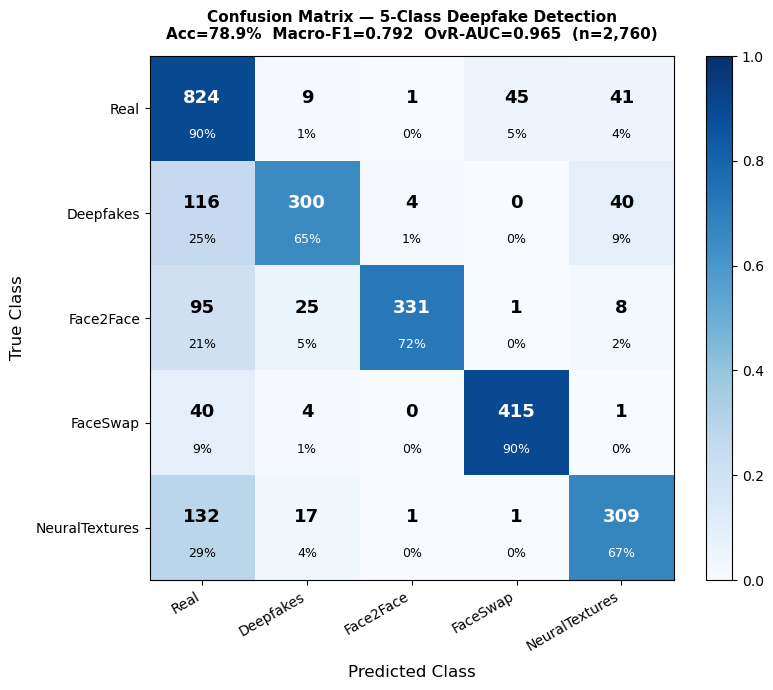

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_confusion_matrix_multiclass(y_true, y_pred, probs,
                                      class_names, save_path=None):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    n       = len(class_names)

    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04)

    for i in range(n):
        for j in range(n):
            dark   = cm_norm[i, j] > 0.5
            color  = 'white' if dark else 'black'
            ax.text(j, i - 0.1, f'{cm[i, j]}',
                    ha='center', va='center', fontsize=13,
                    fontweight='bold', color=color)
            ax.text(j, i + 0.25, f'{cm_norm[i,j]*100:.0f}%',
                    ha='center', va='center', fontsize=9, color=color)

    ax.set_xticks(range(n))
    ax.set_xticklabels(class_names, rotation=30, ha='right', fontsize=10)
    ax.set_yticks(range(n))
    ax.set_yticklabels(class_names, fontsize=10)
    ax.set_xlabel('Predicted Class', fontsize=12, labelpad=8)
    ax.set_ylabel('True Class',      fontsize=12, labelpad=8)

    _, f1, auc, _ = compute_metrics(probs, y_true)
    ax.set_title(
        f'Confusion Matrix — 5-Class Deepfake Detection\n'
        f'Acc={accuracy_score(y_true,y_pred)*100:.1f}%  '
        f'Macro-F1={f1:.3f}  OvR-AUC={auc:.3f}  (n={len(y_true):,})',
        fontsize=11, fontweight='bold', pad=12)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved → {save_path}')
    plt.show()


plot_confusion_matrix_multiclass(
    test_targets, test_preds, test_probs, CLASS_NAMES,
    save_path=os.path.join(cfg.work_dir, 'cm_multiclass.png'))

Saved → C:\Users\DPQUAI250117\Desktop\deep_fake_version_3\output\per_class_metrics.png


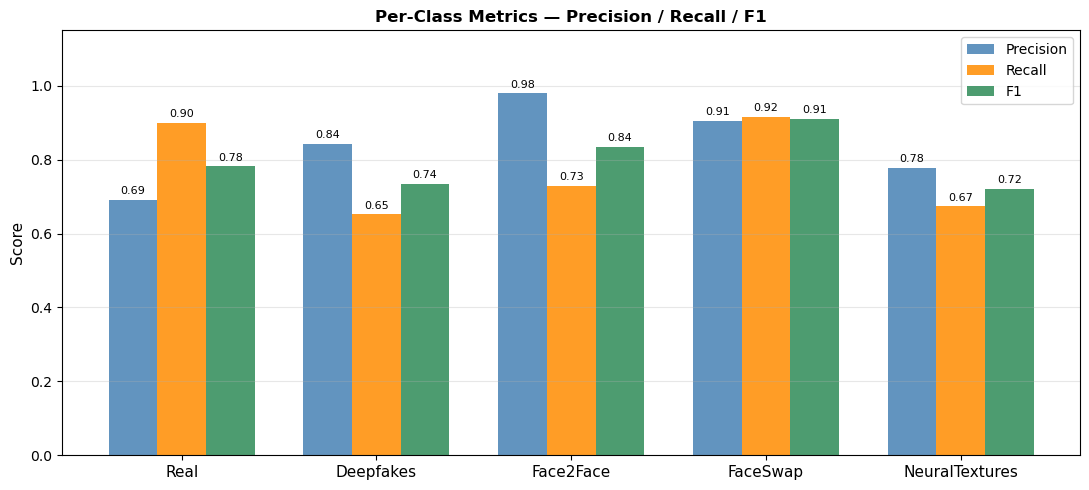


Per-class breakdown:
  Class               Precision     Recall         F1
  ----------------------------------------------------
  Real                   0.6912     0.9000     0.7819
  Deepfakes              0.8427     0.6522     0.7353
  Face2Face              0.9795     0.7283     0.8354
  FaceSwap               0.9054     0.9152     0.9103
  NeuralTextures         0.7769     0.6739     0.7218


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_per_class_metrics(y_true, y_pred, class_names, save_path=None):
    prec = precision_score(y_true, y_pred, average=None, zero_division=0)
    rec  = recall_score   (y_true, y_pred, average=None, zero_division=0)
    f1   = f1_score       (y_true, y_pred, average=None, zero_division=0)

    x = np.arange(len(class_names))
    w = 0.25

    fig, ax = plt.subplots(figsize=(11, 5))
    b1 = ax.bar(x - w, prec, w, label='Precision', color='steelblue',  alpha=0.85)
    b2 = ax.bar(x,     rec,  w, label='Recall',    color='darkorange', alpha=0.85)
    b3 = ax.bar(x + w, f1,   w, label='F1',        color='seagreen',   alpha=0.85)

    for bars in [b1, b2, b3]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(class_names, fontsize=11)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title('Per-Class Metrics — Precision / Recall / F1',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved → {save_path}')
    plt.show()

    print('\nPer-class breakdown:')
    print(f'  {"Class":<18} {"Precision":>10} {"Recall":>10} {"F1":>10}')
    print('  ' + '-' * 52)
    for cls, p, r, f in zip(class_names, prec, rec, f1):
        print(f'  {cls:<18} {p:>10.4f} {r:>10.4f} {f:>10.4f}')


plot_per_class_metrics(
    test_targets, test_preds, CLASS_NAMES,
    save_path=os.path.join(cfg.work_dir, 'per_class_metrics.png'))

Saved → C:\Users\DPQUAI250117\Desktop\deep_fake_version_3\output\training_curves_multiclass.png


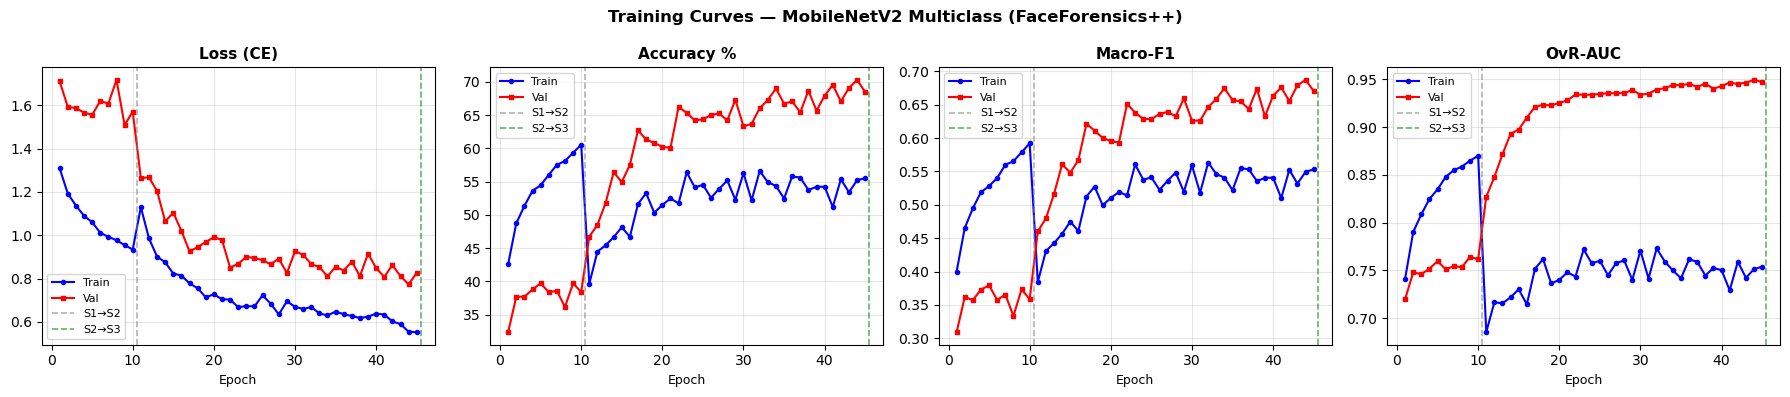

In [ ]:
def plot_training_curves(h1, h2, save_path=None):
    def merge(key):
        return h1.get(key, []) + h2.get(key, [])

    n_total = len(merge('train_acc'))
    epochs  = range(1, n_total + 1)
    s1_len  = len(h1['train_acc'])
    s2_len  = len(h2.get('train_acc', []))
    sep1    = s1_len           # end of Stage 1
    sep2    = s1_len + s2_len  # end of Stage 2  (bug fix: was undefined `sep`)

    keys = [
        ('Loss (CE)',  'train_loss', 'val_loss',  lambda v: v),
        ('Accuracy %', 'train_acc',  'val_acc',   lambda v: v * 100),
        ('Macro-F1',   'train_f1',   'val_f1',    lambda v: v),
        ('OvR-AUC',    'train_auc',  'val_auc',   lambda v: v),
    ]

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    for ax, (title, tr_k, va_k, fn) in zip(axes, keys):
        tr_vals = [fn(v) for v in merge(tr_k)]
        va_vals = [fn(v) for v in merge(va_k)]
        ax.plot(epochs, tr_vals, 'b-o', markersize=3, linewidth=1.5, label='Train')
        ax.plot(epochs, va_vals, 'r-s', markersize=3, linewidth=1.5, label='Val')
        ax.axvline(sep1 + 0.5, color='gray',  linestyle='--', alpha=0.6,
                   linewidth=1.2, label='S1→S2')
        ax.axvline(sep2 + 0.5, color='green', linestyle='--', alpha=0.6,
                   linewidth=1.2, label='S2→S3')
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel('Epoch', fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle(
        'Training Curves — MobileNetV2 Multiclass (FaceForensics++)',
        fontsize=12, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved → {save_path}')
    plt.show()


plot_training_curves(
    history_s1, {k: history_s2.get(k,[])+history_s3.get(k,[]) for k in history_s1},
    save_path=os.path.join(cfg.work_dir, 'training_curves_multiclass.png'))


C:\Users\DPQUAI250117\AppData\Local\Temp\ipykernel_34448\2853346816.py:98: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=120, bbox_inches='tight')
C:\Users\DPQUAI250117\AppData\Local\Temp\ipykernel_34448\2853346816.py:98: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=120, bbox_inches='tight')


Saved → C:\Users\DPQUAI250117\Desktop\deep_fake_version_3\output\gradcam_per_class.png


c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


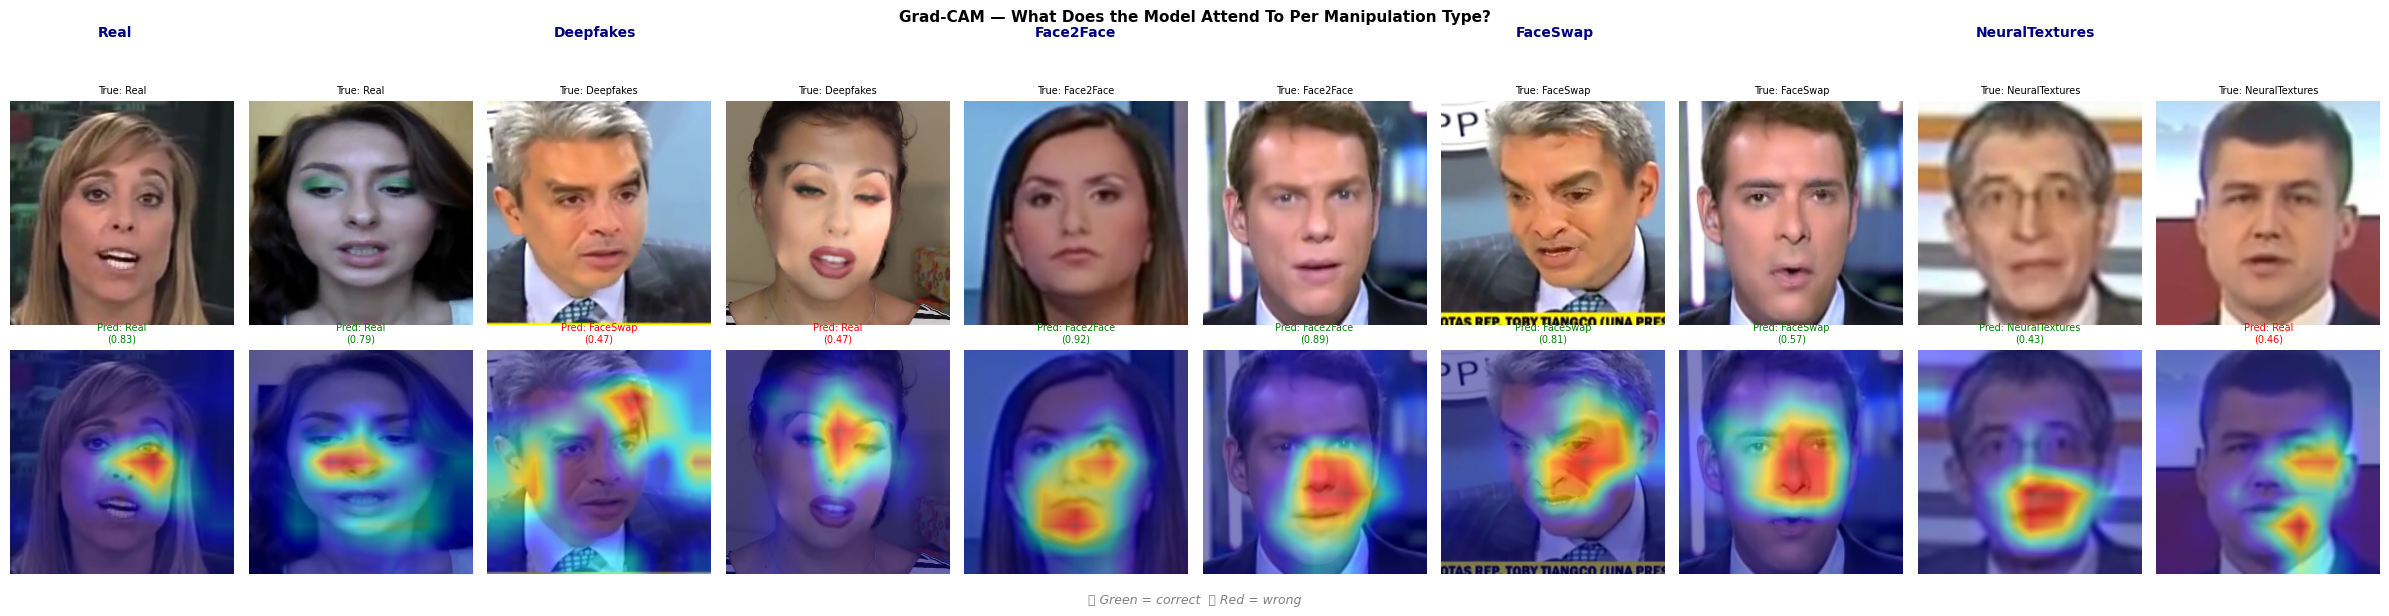

In [ ]:
import cv2

def get_gradcam_heatmap(model, img_tensor, target_class):
    """Grad-CAM on the last conv block of MobileNetV2."""
    model.eval()
    gradients, activations = [], []
    target_layer = model.features[-1]

    fh = target_layer.register_forward_hook(
        lambda m, i, o: activations.append(o.detach()))
    bh = target_layer.register_full_backward_hook(
        lambda m, gi, go: gradients.append(go[0].detach()))

    x = img_tensor.unsqueeze(0).to(DEVICE).requires_grad_(True)
    out = model(x)
    model.zero_grad()
    out[0, target_class].backward()
    fh.remove(); bh.remove()

    grads   = gradients[0].squeeze()          # (C, H, W)
    acts    = activations[0].squeeze()        # (C, H, W)
    weights = grads.mean(dim=(1, 2))          # (C,)
    cam     = torch.relu((weights[:, None, None] * acts).sum(0))
    cam     = cam - cam.min()
    if cam.max() > 0:
        cam = cam / cam.max()
    return cam.cpu().numpy()


def plot_gradcam_per_class(model, test_df, test_tf, n_per_class=2, save_path=None):
    """
    For each of the 5 classes, show n_per_class images with their
    Grad-CAM overlay — highlighting what the model looks at to identify
    each manipulation type.
    """
    model.eval()
    samples = {c: [] for c in range(NUM_CLASSES)}

    for _, row in test_df.sample(frac=1, random_state=42).iterrows():
        cls = int(row['target'])
        if len(samples[cls]) < n_per_class:
            samples[cls].append(row)
        if all(len(v) >= n_per_class for v in samples.values()):
            break

    n_cols = n_per_class * NUM_CLASSES
    fig, axes = plt.subplots(2, n_cols, figsize=(n_cols * 2.4, 5.5))

    col = 0
    for cls_idx in range(NUM_CLASSES):
        for row in samples[cls_idx]:
            img_pil = Image.open(row['path']).convert('RGB')
            img_np  = np.array(img_pil.resize((224, 224)))
            tensor  = test_tf(img_pil)

            with torch.no_grad():
                out       = model(tensor.unsqueeze(0).to(DEVICE))
                probs_row = torch.softmax(out, dim=1)[0].cpu().numpy()
                pred_cls  = int(np.argmax(probs_row))

            # Grad-CAM w.r.t. the TRUE class (what activates for this class)
            cam   = get_gradcam_heatmap(model, tensor, target_class=cls_idx)
            cam_r = cv2.resize(cam, (224, 224))
            hm    = cv2.applyColorMap((cam_r * 255).astype(np.uint8),
                                      cv2.COLORMAP_JET)
            hm    = cv2.cvtColor(hm, cv2.COLOR_BGR2RGB)
            overlay = np.clip(0.5 * img_np + 0.5 * hm, 0, 255).astype(np.uint8)

            pred_name = CLASS_NAMES[pred_cls]
            correct   = pred_cls == cls_idx
            color     = 'green' if correct else 'red'

            axes[0, col].imshow(img_np)
            axes[0, col].set_title(f'True: {CLASS_NAMES[cls_idx]}', fontsize=7)
            axes[0, col].axis('off')

            axes[1, col].imshow(overlay)
            axes[1, col].set_title(
                f'Pred: {pred_name}\n({probs_row[pred_cls]:.2f})',
                fontsize=7, color=color)
            axes[1, col].axis('off')
            col += 1

    # Class group labels at top
    for c_idx in range(NUM_CLASSES):
        mid_col = (c_idx * n_per_class + n_per_class / 2 - 0.5) / n_cols
        fig.text(mid_col, 1.02, CLASS_NAMES[c_idx],
                 ha='center', fontsize=10, fontweight='bold',
                 color='navy')

    fig.text(0.5, -0.01, '✅ Green = correct  ❌ Red = wrong',
             ha='center', fontsize=9, style='italic', color='gray')

    plt.suptitle('Grad-CAM — What Does the Model Attend To Per Manipulation Type?',
                 fontsize=11, fontweight='bold', y=1.07)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
        print(f'Saved → {save_path}')
    plt.show()


plot_gradcam_per_class(
    model, test_df, test_tf, n_per_class=2,
    save_path=os.path.join(cfg.work_dir, 'gradcam_per_class.png'))

Saved → C:\Users\DPQUAI250117\Desktop\deep_fake_version_3\output\confidence_dist.png


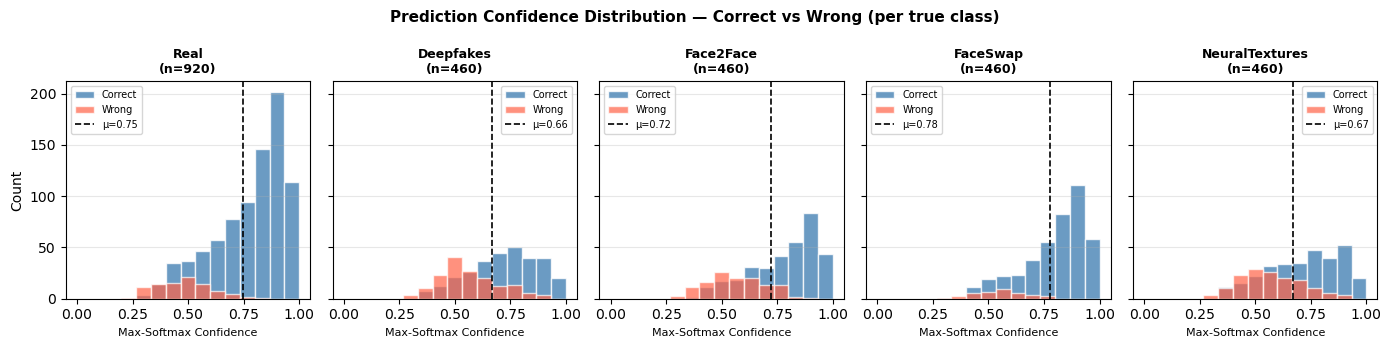

In [ ]:
def plot_confidence_distribution(probs, targets, class_names, save_path=None):
    """
    Distribution of max-softmax confidence (= model certainty) per true class.
    Well-calibrated models should have high confidence on correct predictions.
    """
    max_conf = np.max(probs, axis=1)

    fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(14, 3.5), sharey=True)

    for i, (ax, cls) in enumerate(zip(axes, class_names)):
        mask = targets == i
        if mask.sum() == 0:
            ax.set_title(f'{cls}\n(no samples)', fontsize=9)
            continue

        confs = max_conf[mask]
        # Correct vs wrong confidence
        preds_cls = np.argmax(probs[mask], axis=1)
        correct_m = preds_cls == i

        ax.hist(confs[correct_m],  bins=15, range=(0,1), alpha=0.8,
                color='steelblue', label='Correct', edgecolor='white')
        ax.hist(confs[~correct_m], bins=15, range=(0,1), alpha=0.7,
                color='tomato',    label='Wrong',   edgecolor='white')
        ax.axvline(confs.mean(), color='black', linestyle='--', linewidth=1.2,
                   label=f'μ={confs.mean():.2f}')

        ax.set_title(f'{cls}\n(n={mask.sum()})', fontsize=9, fontweight='bold')
        ax.set_xlabel('Max-Softmax Confidence', fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(axis='y', alpha=0.3)

    axes[0].set_ylabel('Count', fontsize=10)
    plt.suptitle('Prediction Confidence Distribution — Correct vs Wrong (per true class)',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved → {save_path}')
    plt.show()


plot_confidence_distribution(
    test_probs, test_targets, CLASS_NAMES,
    save_path=os.path.join(cfg.work_dir, 'confidence_dist.png'))

Total errors: 724 / 2760 (26.2%)
Saved → C:\Users\DPQUAI250117\Desktop\deep_fake_version_3\output\error_analysis_multiclass.png


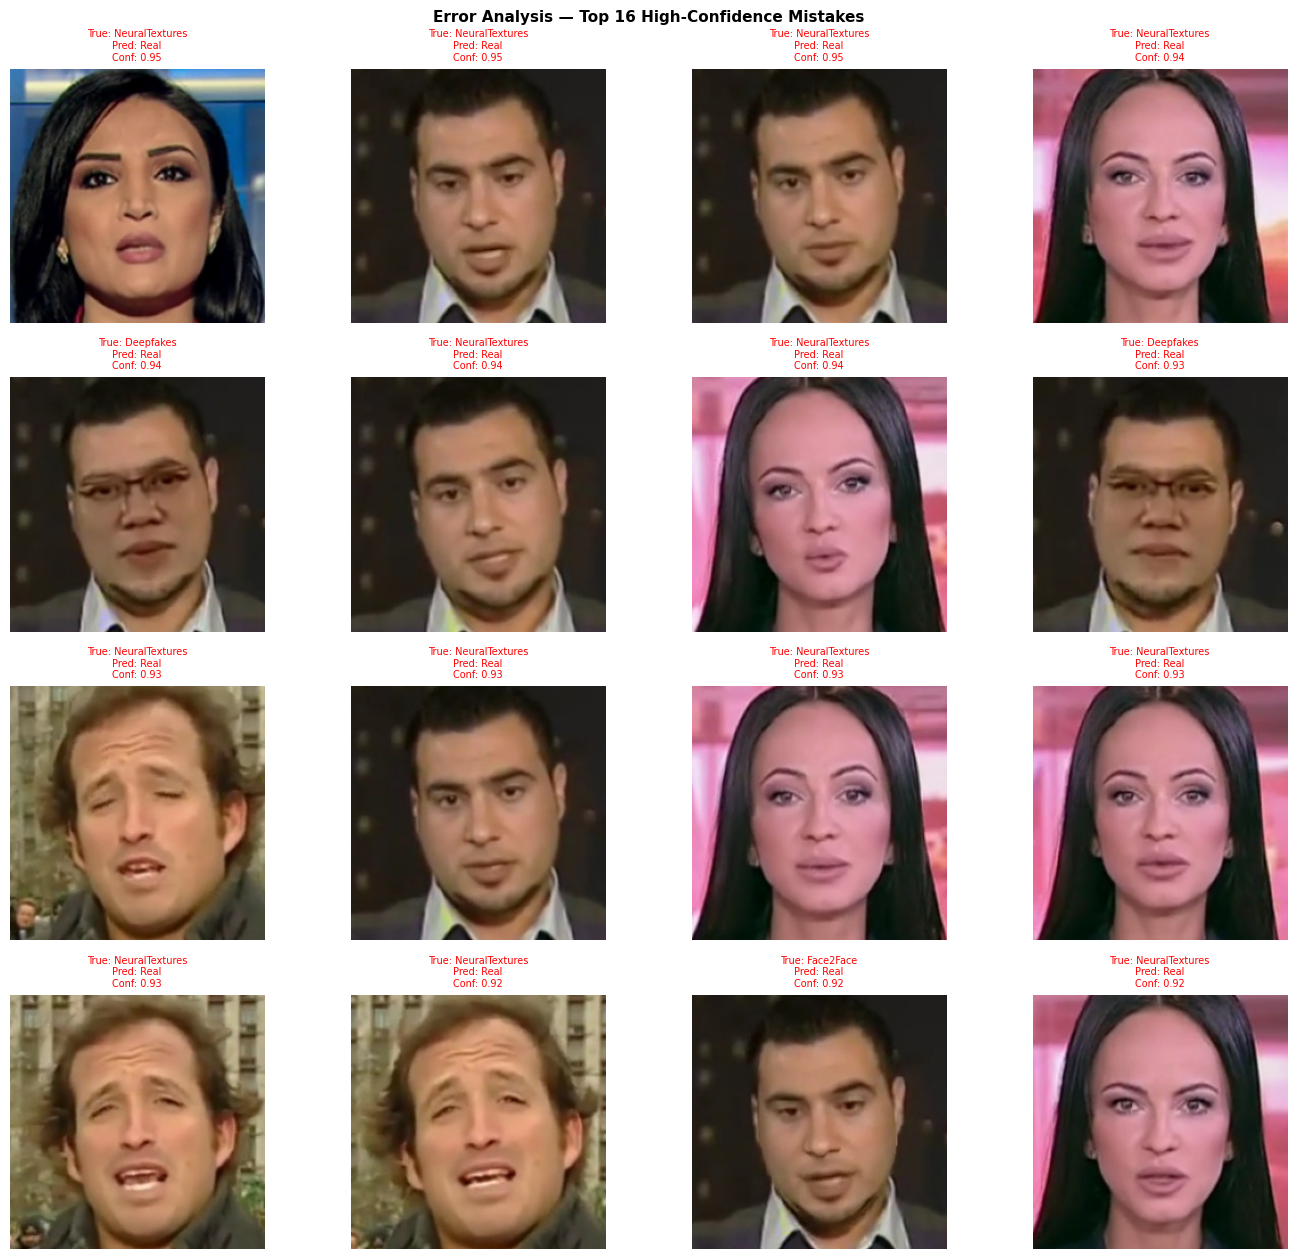


Confusion breakdown (true → predicted), top errors:
      NeuralTextures → Real: 13
           Deepfakes → Real: 2
           Face2Face → Real: 1


In [ ]:
def plot_error_analysis_multiclass(model, test_df, test_tf,
                                    n=16, save_path=None):
    """Top-n high-confidence mistakes with true→pred breakdown."""
    model.eval()
    errors = []

    with torch.no_grad():
        for _, row in test_df.iterrows():
            img   = Image.open(row['path']).convert('RGB')
            x     = test_tf(img).unsqueeze(0).to(DEVICE)
            out   = model(x)
            probs = torch.softmax(out, dim=1)[0].cpu().numpy()
            pred  = int(np.argmax(probs))
            true  = int(row['target'])
            if pred != true:
                errors.append({
                    'path'      : row['path'],
                    'true'      : true,
                    'pred'      : pred,
                    'confidence': float(probs[pred]),   # confidence in wrong pred
                    'probs'     : probs,
                })

    print(f'Total errors: {len(errors)} / {len(test_df)} '
          f'({100*len(errors)/len(test_df):.1f}%)')

    top_errors = sorted(errors, key=lambda e: e['confidence'], reverse=True)[:n]

    cols = 4
    rows = max(1, (n + cols - 1) // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.2))
    axes = axes.flatten()

    for i, err in enumerate(top_errors):
        img = Image.open(err['path']).convert('RGB').resize((224, 224))
        axes[i].imshow(img)
        t_name = CLASS_NAMES[err['true']]
        p_name = CLASS_NAMES[err['pred']]
        axes[i].set_title(
            f'True: {t_name}\nPred: {p_name}\nConf: {err["confidence"]:.2f}',
            fontsize=7, color='red')
        axes[i].axis('off')

    for j in range(len(top_errors), len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'Error Analysis — Top {n} High-Confidence Mistakes',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
        print(f'Saved → {save_path}')
    plt.show()

    # Confusion summary
    print('\nConfusion breakdown (true → predicted), top errors:')
    err_pairs = {}
    for e in top_errors:
        key = f'{CLASS_NAMES[e["true"]]:>18} → {CLASS_NAMES[e["pred"]]}'
        err_pairs[key] = err_pairs.get(key, 0) + 1
    for k, v in sorted(err_pairs.items(), key=lambda x: -x[1]):
        print(f'  {k}: {v}')


plot_error_analysis_multiclass(
    model, test_df, test_tf, n=16,
    save_path=os.path.join(cfg.work_dir, 'error_analysis_multiclass.png'))

In [ ]:
# SAVE / LOAD / INFERENCE

# Save final weights
final_path = os.path.join(cfg.work_dir, 'deepfake_multiclass_final.pth')
torch.save(model.state_dict(), final_path)
print(f'Model saved → {final_path}')


# Load helper
def load_model(path):
    m = build_model(freeze_backbone=False)
    m.load_state_dict(torch.load(path, map_location=DEVICE))
    m.eval()
    print(f'Model loaded ← {path}')
    return m


# Single-image inference
def predict_image(img_path, model):
    """
    Predict which of the 5 classes an image belongs to.
    Returns (class_name, prob_vector).
    """
    tf = transforms.Compose([
        transforms.Resize((cfg.image_size, cfg.image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    img  = Image.open(img_path).convert('RGB')
    x    = tf(img).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        out   = model(x)
        probs = torch.softmax(out, dim=1)[0].cpu().numpy()

    pred_idx   = int(np.argmax(probs))
    pred_label = CLASS_NAMES[pred_idx]

    print(f'\nImage      : {os.path.basename(img_path)}')
    print(f'Prediction : {pred_label}  (confidence={probs[pred_idx]:.4f})')
    print('All probs  :')
    for cls, p in zip(CLASS_NAMES, probs):
        bar = '█' * int(p * 30)
        marker = ' ← predicted' if cls == pred_label else ''
        print(f'  {cls:<18}  {p:.4f}  {bar}{marker}')

    return pred_label, probs


# Usage example
# img_path = r'C:\path\to\your\face_frame.jpg'   # ← change this
# if os.path.exists(img_path):
#     label, probs = predict_image(img_path, model)
# else:
#     print(f'File not found: {img_path}')
print('\nInference function ready. Update img_path and uncomment above to test.')

Model saved → C:\Users\DPQUAI250117\Desktop\deep_fake_version_3\output\deepfake_multiclass_final.pth

Inference function ready. Update img_path and uncomment above to test.
